In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip "/content/drive/MyDrive/asl_model/archive (1).zip" -d "/content/dataset"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/273a7a9e-18be-4b6a-976a-fa5ffd69b731___RS_HL 4366_90deg.JPG  
  inflating: /content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_90deg.JPG  
  inflating: /content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_new30degFlipLR.JPG  
  inflating: /content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665.JPG  
  inflating: /content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2

In [ ]:
!ls "/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

train  valid


In [ ]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    format="tf",
    verbose=True,
)


Found 70295 files belonging to 38 classes.


In [ ]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    format="tf",
    verbose=True,
)


Found 17572 files belonging to 38 classes.


In [ ]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout,MaxPooling2D,GlobalAveragePooling2D
from tensorflow.keras.models import Sequential


In [ ]:
model=Sequential()

In [ ]:
model.add(Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(128,128,3)))
model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))


In [ ]:
model.add(Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))


In [ ]:
model.add(Conv2D(filters=128,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))


In [ ]:
model.add(Conv2D(filters=256,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))


In [ ]:
model.add(Dropout(0.25))

In [ ]:
model.add(Flatten())

In [ ]:
model.add(Dense(units=1024,activation='relu'))

In [ ]:
model.add(Dense(units=512,activation='relu'))

In [ ]:
model.add(Dropout(0.4))

In [ ]:
model.add(Dense(units=38,activation='softmax'))

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,154,758 (42.55 MB)

 Trainable params: 11,154,758 (42.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
training_history=model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 132s 57ms/step - accuracy: 0.4409 - loss: 1.9219 - val_accuracy: 0.7174 - val_loss: 0.8972
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 129s 59ms/step - accuracy: 0.7404 - loss: 0.8247 - val_accuracy: 0.8296 - val_loss: 0.5357
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 128s 58ms/step - accuracy: 0.8205 - loss: 0.5683 - val_accuracy: 0.8440 - val_loss: 0.4916
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 128s 58ms/step - accuracy: 0.8522 - loss: 0.4622 - val_accuracy: 0.8672 - val_loss: 0.4043
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 120s 55ms/step - accuracy: 0.8739 - loss: 0.3989 - val_accuracy: 0.8812 - val_loss: 0.3797
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 119s 54ms/step - accuracy: 0.8854 - loss: 0.3597 - val_accuracy: 0.8774 - val_loss: 0.3826
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 119s 54ms/step - accuracy: 0.8916 - loss: 0.3416 - val_accuracy: 0.8886 - val_loss: 0.3630
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 119s 54ms/step - accuracy: 

In [ ]:
model_2 = tf.keras.Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(256,(3,3),activation='relu'),
    Conv2D(256,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(38,activation='softmax')
])

In [ ]:
model_2.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,247,814 (4.76 MB)

 Trainable params: 1,247,814 (4.76 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
training_history_2=model_2.fit(training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 129s 54ms/step - accuracy: 0.4359 - loss: 1.9749 - val_accuracy: 0.7566 - val_loss: 0.8318
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 49ms/step - accuracy: 0.7556 - loss: 0.8106 - val_accuracy: 0.8471 - val_loss: 0.4889
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 117s 53ms/step - accuracy: 0.8427 - loss: 0.5154 - val_accuracy: 0.9181 - val_loss: 0.2614
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 118s 54ms/step - accuracy: 0.8881 - loss: 0.3590 - val_accuracy: 0.9298 - val_loss: 0.2234
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 118s 54ms/step - accuracy: 0.9111 - loss: 0.2807 - val_accuracy: 0.9446 - val_loss: 0.1700
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 49ms/step - accuracy: 0.9288 - loss: 0.2249 - val_accuracy: 0.9581 - val_loss: 0.1322
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 117s 53ms/step - accuracy: 0.9421 - loss: 0.1817 - val_accuracy: 0.9595 - val_loss: 0.1235
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 49ms/step - accuracy: 

In [ ]:
model_2.save("plant_disease_model.keras")

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_2)
tflite_model = converter.convert()

with open("plant_model.tflite","wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpfpk0pbxu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_309')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  138287948809232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138287948812112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138287948812688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138287948811920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138287948813264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138287948813072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138287948813648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138287948813456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138287948814032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138287948813840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138287948

In [ ]:
test_set= tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    format="tf",
    verbose=True,
)


Found 17572 files belonging to 38 classes.


In [ ]:
y_pred=model_2.predict(test_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step


In [ ]:
print(y_pred,y_pred.shape)

[[9.9999881e-01 1.7348953e-09 2.4639205e-10 ... 6.4618030e-15
  4.4930990e-16 2.8487860e-11]
 [9.9999785e-01 2.4945868e-08 2.8247575e-09 ... 5.9796058e-15
  6.4204409e-16 2.3343431e-11]
 [1.0000000e+00 2.8778162e-11 1.0600002e-12 ... 4.0497501e-22
  5.4529867e-22 8.2103564e-15]
 ...
 [3.1621633e-10 3.2321511e-12 3.7406309e-09 ... 7.2232233e-12
  1.9219506e-11 9.9999726e-01]
 [6.8377721e-09 2.8117451e-09 1.9022227e-07 ... 1.2367083e-09
  3.5105110e-09 9.9998689e-01]
 [1.4202777e-16 2.8853462e-18 2.8533567e-15 ... 3.9198161e-19
  2.1822519e-15 9.9999988e-01]] (17572, 38)


In [ ]:
predicted_category=tf.argmax(y_pred,axis=1)

In [ ]:
predicted_category

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [ ]:
labels = test_set.class_names

with open("labels.txt", "w") as f:
    for label in labels:
        f.write(label + "\n")

In [ ]:
print(len(test_set.class_names))

38


In [ ]:
import cv2

In [ ]:
image_path="/content/dataset/test/test/CornCommonRust1.JPG"

In [ ]:
img1=cv2.imread(image_path)

In [ ]:
img1=cv2.cvtColor(img1,cv2.COLOR_BGR2RGB)

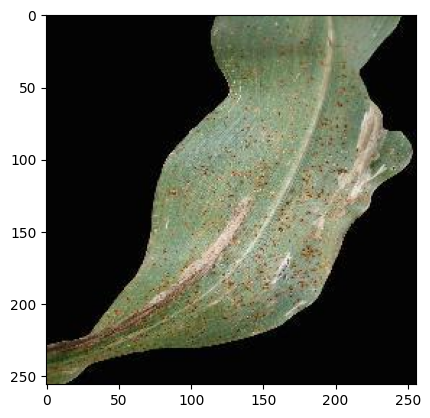

In [ ]:
plt.imshow(img1)

In [ ]:
image=tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr=tf.keras.preprocessing.image.img_to_array(image)
input_arr=np.array([input_arr])
print(input_arr.shape)

(1, 128, 128, 3)


In [ ]:
prediction=model_2.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [ ]:
prediction,prediction.shape

(array([[3.1880237e-22, 2.0038608e-23, 5.8971250e-20, 6.2768315e-21,
         8.4563207e-23, 1.5299572e-22, 3.8655078e-22, 1.5736150e-10,
         1.0000000e+00, 1.0667896e-18, 1.9591876e-25, 8.4416510e-24,
         3.6750908e-24, 3.1635338e-26, 1.7545245e-24, 3.4941141e-22,
         2.6157846e-28, 4.9705080e-25, 2.3048289e-23, 4.5031163e-20,
         4.5138111e-21, 9.6187502e-29, 5.8645841e-24, 3.9895011e-24,
         2.8962053e-28, 6.1674713e-25, 3.2967829e-23, 3.7995288e-30,
         7.5556463e-26, 1.2472532e-22, 3.4183153e-17, 2.8246838e-27,
         9.0411656e-26, 2.8256172e-30, 5.3992716e-30, 1.0353907e-22,
         2.1164767e-36, 3.6962768e-25]], dtype=float32),
 (1, 38))

In [ ]:
result_index=np.argmax(prediction)
result_index

np.int64(8)

In [ ]:
labels[result_index]

'Corn_(maize)___Common_rust_'

In [ ]:
true_categories=tf.concat([y for x,y in test_set],axis=0)

In [ ]:
y_true=tf.argmax(true_categories,axis=1)

In [ ]:
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
print(classification_report(y_true,predicted_category,target_names=labels))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.96      0.97       504
                                 Apple___Black_rot       0.98      0.99      0.99       497
                          Apple___Cedar_apple_rust       0.96      0.98      0.97       440
                                   Apple___healthy       0.98      0.95      0.96       502
                               Blueberry___healthy       0.98      0.96      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.99      0.99       421
                 Cherry_(including_sour)___healthy       1.00      0.98      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.95      0.92       410
                       Corn_(maize)___Common_rust_       0.99      0.98      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.96      0.94      0.

In [ ]:
cm=confusion_matrix(y_true,predicted_category)
cm

array([[485,   3,   1, ...,   0,   0,   0],
       [  0, 494,   0, ...,   0,   0,   0],
       [  0,   0, 433, ...,   0,   0,   1],
       ...,
       [  0,   0,   0, ..., 486,   0,   0],
       [  0,   0,   0, ...,   0, 446,   0],
       [  0,   0,   1, ...,   0,   0, 472]])

<Axes: >

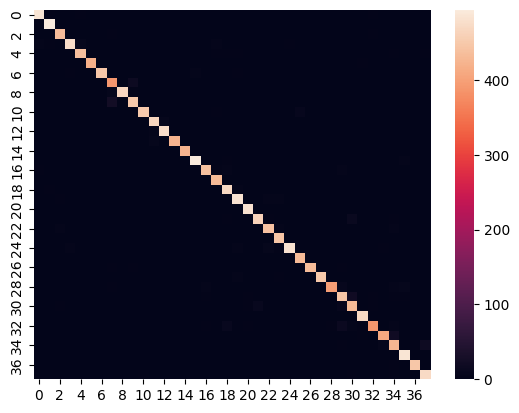

In [ ]:
sns.heatmap(cm)